In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.2 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import time
from pathlib import Path
from ultralytics import YOLO
from collections import deque
import numpy as np
from google.colab import drive
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import shutil
import random
import yaml
import pandas as pd

In [ ]:
drive.mount('/content/drive')

# **Load and Visualize the Data with its Labels**

In [ ]:
# Dataset path
dataset = '/content/drive/MyDrive/door_case/dataset/full'
images_path = os.path.join(dataset, "images")
labels_path = os.path.join(dataset, "labels")

In [ ]:
classes = {
    0: "close_door",
    1: "open_door",
    2: "semi_door"
}

In [ ]:
# Initialize a counter for each class with 0
counts = {name: 0 for name in classes.values()}
labels_path = os.path.join(dataset, "labels")

# Loop over all label
for f in os.listdir(labels_path):
  if f.endswith(".txt"):
    with open(os.path.join(labels_path, f), "r") as file:
      line = file.readline().strip()
      if line:
        cls_id = int(line.split()[0])
        class_name = classes[cls_id]
        counts[class_name] += 1

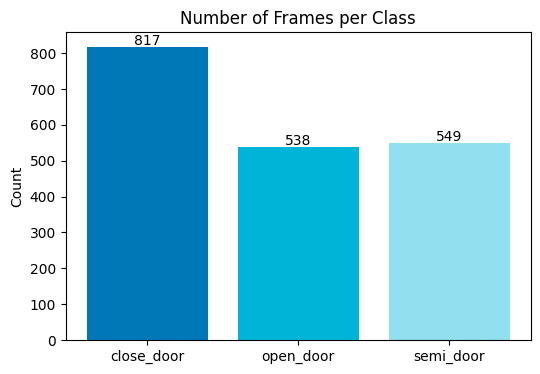

In [ ]:
# Plot
plt.figure(figsize=(6,4))
plt.bar(counts.keys(), counts.values(), color=['#0077b6','#00b4d8','#90e0ef'])
plt.title("Number of Frames per Class")
plt.ylabel("Count")

# Add numeric value on top of each bar
for i, (cls, cnt) in enumerate(counts.items()):
    plt.text(i, cnt + 5, str(cnt), ha='center', fontsize=10)

plt.show()

In [ ]:
# Function to draw YOLO bounding boxes
def draw_bbox(img, label_path):
    h, w = img.shape[:2] # Get image height & width

    # Read label file line by line
    with open(label_path, "r") as f:
        for line in f:
            # YOLO format: class x_center y_center width height
            c, xc, yc, bw, bh = map(float, line.split())

            # Convert coordinates to pixel
            x1 = int((xc - bw/2) * w)
            y1 = int((yc - bh/2) * h)
            x2 = int((xc + bw/2) * w)
            y2 = int((yc + bh/2) * h)

            # Draw rectangl on the image
            if c == 0:
              cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
            elif c == 1:
              cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            else:
              cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)
    return img

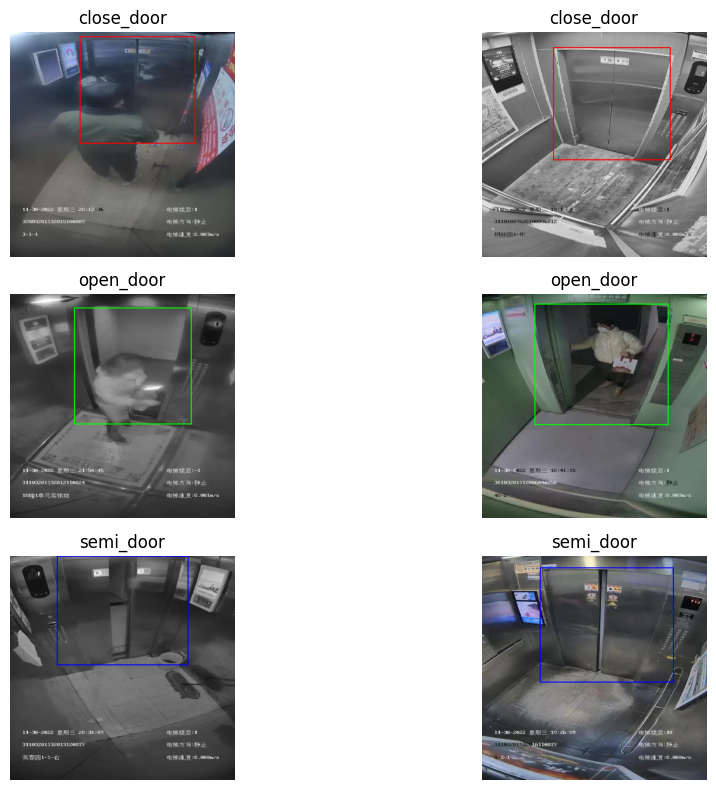

In [ ]:
# Display 2 samples per class

plt.figure(figsize=(12, 8))
idx = 1 # Subplot index

for cls_id, cls_name in classes.items():
    # Get all label files
    class_labels = [
        f for f in os.listdir(labels_path)
        if f.endswith(".txt") and int(open(os.path.join(labels_path, f)).read().split()[0]) == cls_id
    ]

    # Take 2 random samples from this class
    sample_labels = random.sample(class_labels, 2)

    for lb in sample_labels:
        # Matching image name with label
        img_name = lb.replace(".txt", ".jpg")

        img_path = os.path.join(images_path, img_name)
        label_path = os.path.join(labels_path, lb)

        # Load and convert image to RGB
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Draw the bounding box
        img = draw_bbox(img, label_path)

        # Show image in a subplot
        plt.subplot(3, 2, idx)
        plt.imshow(img)
        plt.title(cls_name)
        plt.axis("off")
        idx += 1

plt.tight_layout()
plt.show()

# **Split the dataset**

In [ ]:
output_path = "/content/drive/MyDrive/door_case/splitted_dataset"
if os.path.exists(output_path):
    shutil.rmtree(output_path)

# Create empty folders for the split each with images and labels
for split in ["train", "val", "test"]:
    os.makedirs(f"{output_path}/{split}/images", exist_ok=True)
    os.makedirs(f"{output_path}/{split}/labels", exist_ok=True)

In [ ]:
# Function to extract the video name
def get_video_name(filename):
    return filename.split("-")[0].lower()

In [ ]:
# Dictionary for the video with list of its frames
video_dict = {}
all_files = os.listdir(images_path)

for f in all_files:
    if f.endswith(".jpg"):
        vid = get_video_name(f)
        video_dict.setdefault(vid, []).append(f)

In [ ]:
# Shuffle the list of videos to make random split
video_list = list(video_dict.keys())
random.shuffle(video_list)

In [ ]:
# Compue split sizes (70% train, 20% val, 10% test)
total = len(video_list)
train_end = int(total * 0.7)
val_end   = int(total * 0.9)

train_vids = video_list[:train_end]
val_vids   = video_list[train_end:val_end]
test_vids  = video_list[val_end:]

#Store in dictionary
sets = {
    "train": train_vids,
    "val": val_vids,
    "test": test_vids
}

In [ ]:
# Copy the images and labels to their new split folders
for split, vids in sets.items():
    print(f"{split}: {len(vids)} videos")

    for vid in vids: # Loop on video
        for img in video_dict[vid]: # Loop on all frames of that video
            img_src = os.path.join(images_path, img)
            lbl_src = os.path.join(labels_path, img.replace(".jpg", ".txt"))

            img_dst = os.path.join(output_path, split, "images", img)
            lbl_dst = os.path.join(output_path, split, "labels", img.replace(".jpg", ".txt"))

            shutil.copy(img_src, img_dst) # Copy image
            shutil.copy(lbl_src, lbl_dst) # Copy its label

print("\nDone\nvideo-based splitting created.")

train: 224 videos
val: 64 videos
test: 33 videos

Done
video-based splitting created.


In [ ]:
splits = {
    "train": "/content/drive/MyDrive/door_case/splitted_dataset/train/labels",
    "val": "/content/drive/MyDrive/door_case/splitted_dataset/val/labels",
    "test": "/content/drive/MyDrive/door_case/splitted_dataset/test/labels"
}

all_results = {}

# Loop through each split and count how many samples belong to each class
for split, label_folder in splits.items():
    class_counts = {0: 0, 1: 0, 2: 0} # Class ID : Count start with 0

    # Loop over all label files
    for f in os.listdir(label_folder):
      if f.endswith(".txt"):
        path = os.path.join(label_folder, f)

        with open(path, "r") as file:
          lines = file.readlines()

          # Extract the class ID from the first line of the label file
          cls_id = int(lines[0].split()[0])
          class_counts[cls_id] += 1

    all_results[split] = class_counts

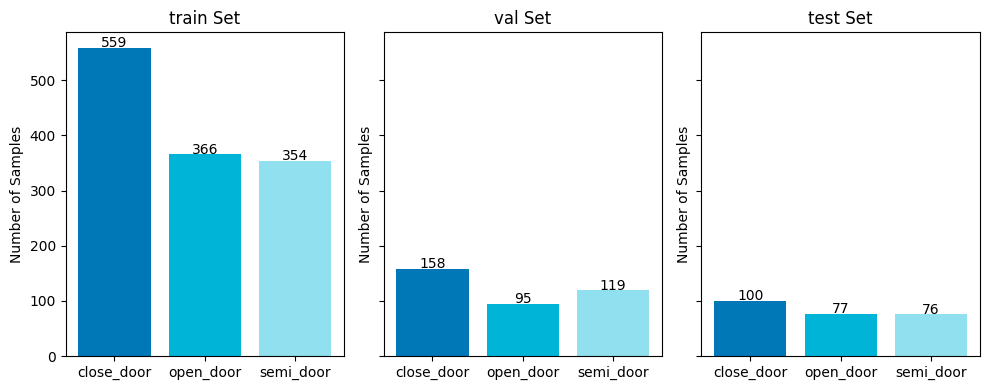

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharey=True)
for idx, (split, counts) in enumerate(all_results.items()):
    ax = axes[idx]

    # Craete bar chart for the split
    ax.bar(
        ["close_door", "open_door", "semi_door"],
        [counts[0], counts[1], counts[2]],
        color=['#0077b6','#00b4d8','#90e0ef']
    )

    ax.set_title(f"{split} Set")
    ax.set_ylabel("Number of Samples")

    # Write the total above the bars
    for i, v in enumerate([counts[0], counts[1], counts[2]]):
        ax.text(i, v + 1, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# **YOLO Configuration & Fine-Tuning**

In [ ]:
# Create the YAML file
yolo_yaml = "/content/drive/MyDrive/door_case/data.yaml"

# Create the YAML content
yaml_content = """
train: /content/drive/MyDrive/door_case/splitted_dataset/train/images
val: /content/drive/MyDrive/door_case/splitted_dataset/val/images
test: /content/drive/MyDrive/door_case/splitted_dataset/test/images

nc: 3
names: ['close_door', 'open_door', 'semi_door']
"""

with open(yolo_yaml,'w') as f:
    f.write(yaml_content.strip())

In [ ]:
model = YOLO('yolo11n.pt')

In [ ]:
torch.cuda.is_available()

In [ ]:
results = model.train(
    data = yolo_yaml,
    epochs = 70,
    imgsz = 640,
    batch = 16,
    optimizer = 'SGD',
    name = '/content/drive/MyDrive/door_case/yolov11_custom_train',
    augment = True
)

Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/door_case/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=70, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov11_custom_train, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, patience=100, perspect

# **Model Testing & Evaluation**

In [ ]:
model_path = '/content/drive/MyDrive/door_case/yolov11_custom_train/weights/best.pt'
yolo_yaml = '/content/drive/MyDrive/door_case/data.yaml'
model = YOLO(model_path)
metrics =  model.val(data = yolo_yaml, imgsz=640, split ="test")

Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 3.0±5.3 ms, read: 0.2±0.2 MB/s, size: 47.6 KB)
val: Scanning /content/drive/MyDrive/door_case/splitted_dataset/test/labels... 253 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 253/253 2.2it/s 1:56
val: New cache created: /content/drive/MyDrive/door_case/splitted_dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 2.8it/s 5.8s
                   all        253        253      0.958      0.963       0.99      0.718
            close_door        100        100      0.988       0.97      0.994      0.743
             open_door         77         77      0.938      0.989      0.994      0.701
             semi_door         76         76      0.946      0.931      0.982      0.709
Speed: 4.0ms preprocess,

In [ ]:
precision = round(float(metrics.box.mp), 3)
recall = round(float(metrics.box.mr), 3)
map50 = round(float(metrics.box.map50), 3)
map5095 = round(float(metrics.box.map), 3)

print("\nYOLO Evaluation Results")
print(f" Precision   : {precision}")
print(f" Recall      : {recall}")
print(f" mAP@50      : {map50}")
print(f" mAP@50-95   : {map5095}")



YOLO Evaluation Results
 Precision   : 0.958
 Recall      : 0.963
 mAP@50      : 0.99
 mAP@50-95   : 0.718


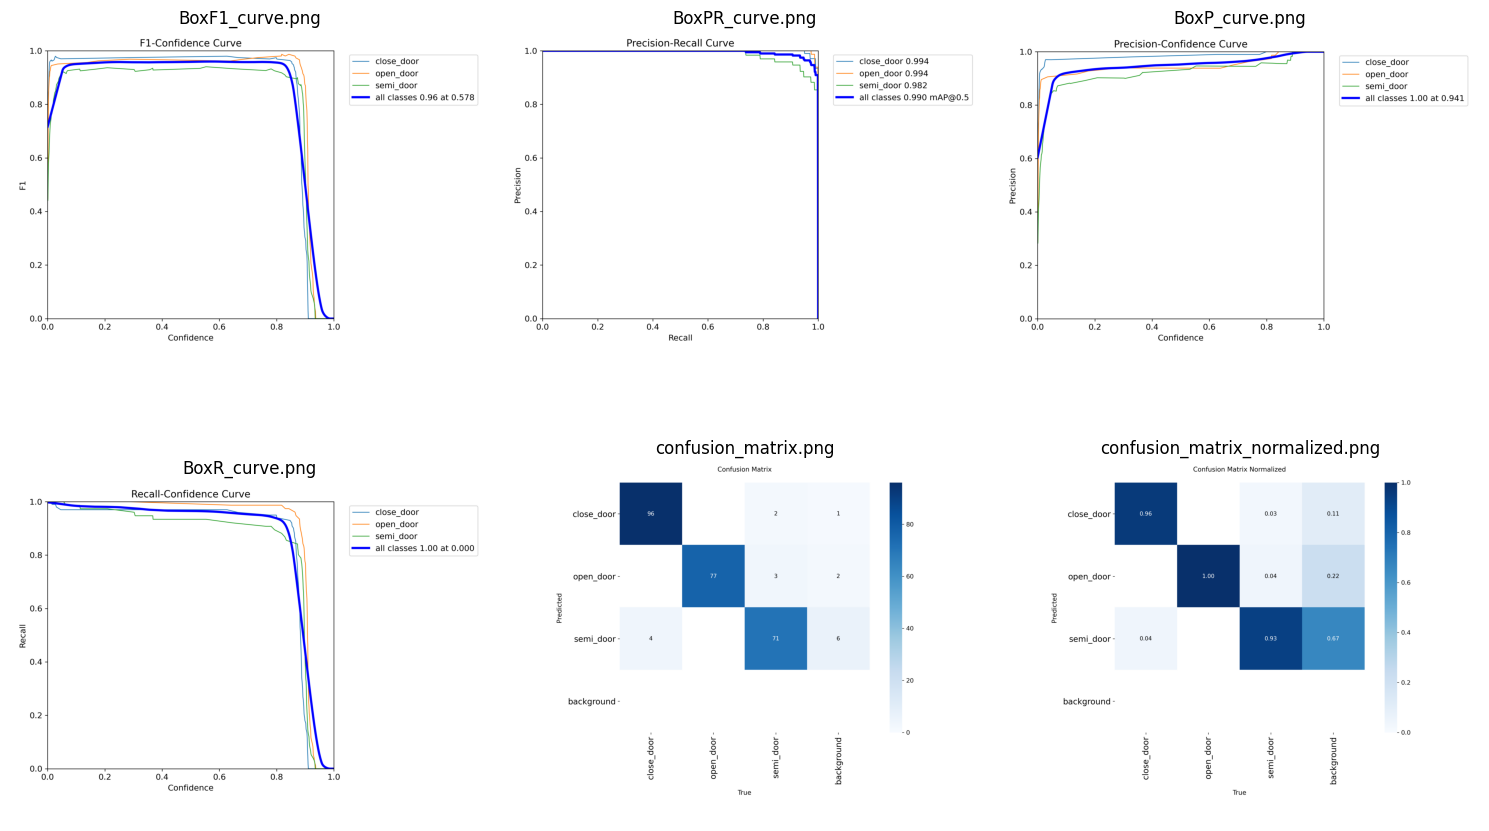

In [ ]:
# Path to YOLO testing result images
path = "/content/drive/MyDrive/door_case/runs/detect/val"

# Get all png and jpg images
imgs = sorted([f for f in os.listdir(path) if f.endswith((".png",".jpg"))])

#Select the first 6 (exclude val_batch images)
main_imgs = [i for i in imgs if not i.startswith("val_batch")][:6]

plt.figure(figsize=(15,10))
for i, name in enumerate(main_imgs):
    img = cv2.cvtColor(cv2.imread(f"{path}/{name}"), cv2.COLOR_BGR2RGB)
    plt.subplot(2,3,i+1); plt.imshow(img); plt.title(name); plt.axis("off")

plt.tight_layout(); plt.show()

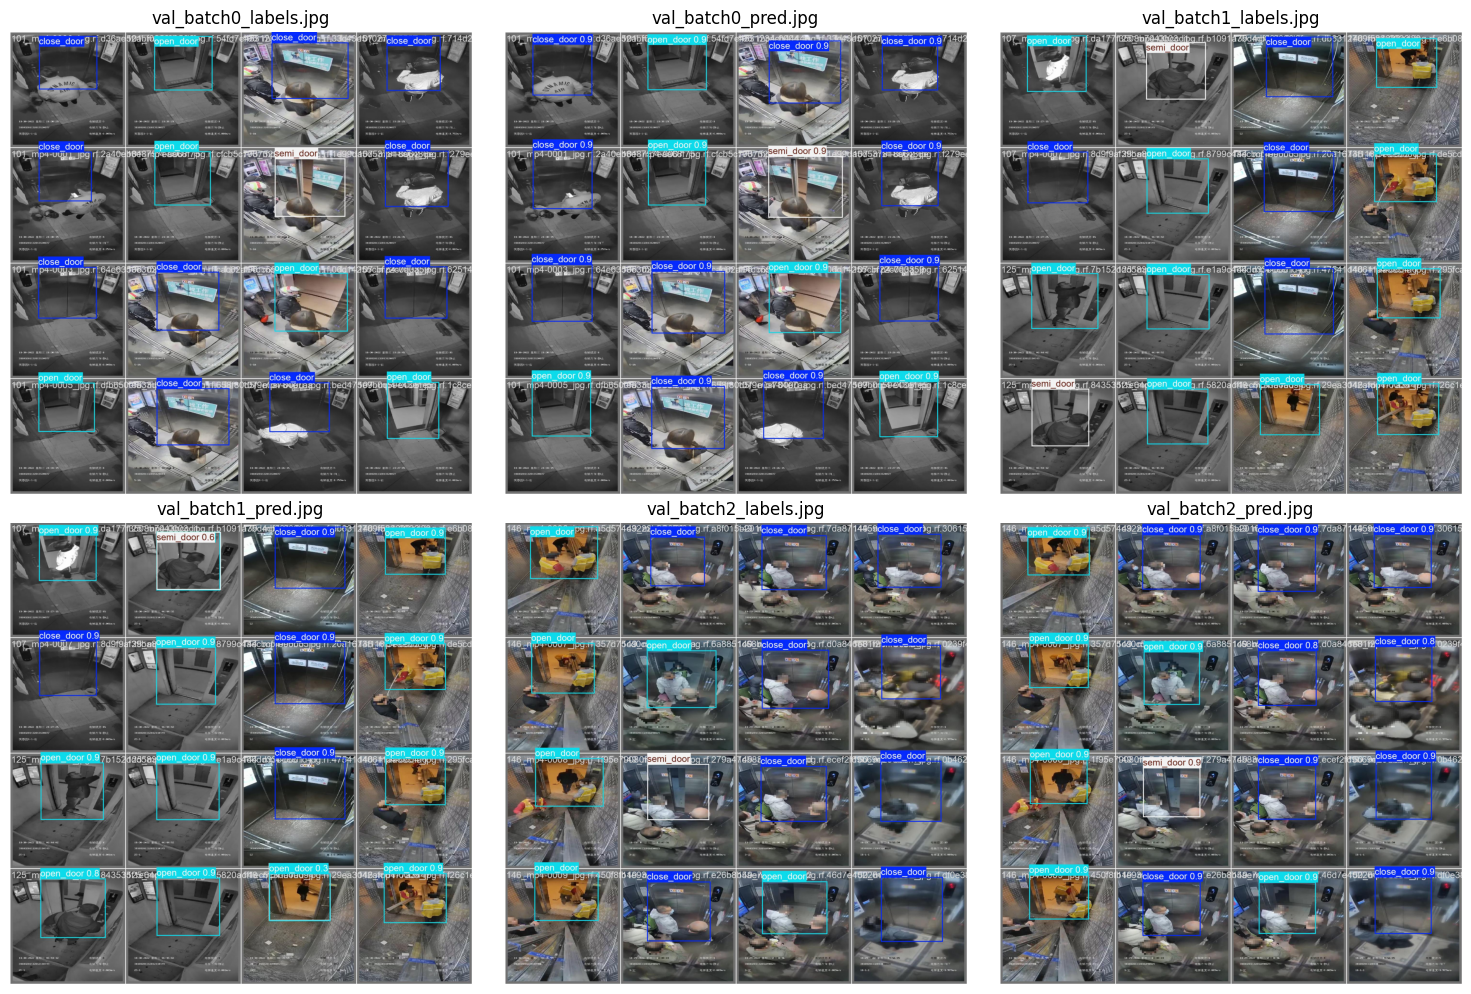

In [ ]:
# Get all val_batch images
val_imgs = sorted([i for i in imgs if i.startswith("val_batch")])

plt.figure(figsize=(15,10))
for i, name in enumerate(val_imgs):
    img = cv2.cvtColor(cv2.imread(f"{path}/{name}"), cv2.COLOR_BGR2RGB)
    plt.subplot(2,3,i+1); plt.imshow(img); plt.title(name); plt.axis("off")

plt.tight_layout(); plt.show()

# **BILSTM Door**

In [ ]:
Data_path = "/content/drive/My Drive/Doorset-ToUse"

print("Dataset path set to:", Data_path)
print("Subfolders:", os.listdir(Data_path))

Mounted at /content/drive
Dataset path set to: /content/drive/My Drive/Doorset-ToUse
Subfolders: ['test', 'train', 'val']


In [ ]:
videos_folder = Path(r"/content/drive/My Drive/OneDrive_1_3-26-2026 (Unzipped Files)")
model_path = Path(r"/content/drive/My Drive/YOLO-Door.pt")
model = YOLO(model_path)

In [ ]:
def list_videos(split):
    root = os.path.join(Data_path, split)
    files = []

    for label in ["NormalDoor", "LagDoor"]:
        label_dir = os.path.join(root, label)
        if not os.path.exists(label_dir):
            continue

        for f in os.listdir(label_dir):
            name = os.path.splitext(f)[0].lower()
            files.append(label + "/" + name)

    return set(files)


train = list_videos("train")
val   = list_videos("val")
test  = list_videos("test")

print("Train ∩ Val :", len(train & val))
print("Train ∩ Test:", len(train & test))
print("Val ∩ Test  :", len(val & test))

Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0


Normal Door: [120, 14, 13]
Faulty Door: [120, 40, 40]


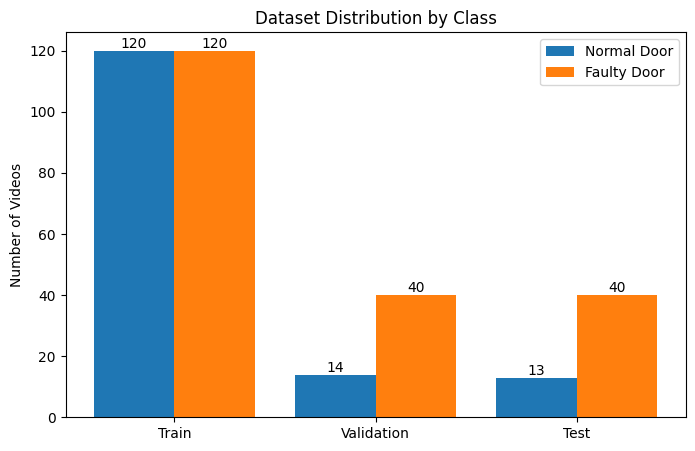

In [ ]:
def count_videos(split, label):
    path = os.path.join(Data_path, split, label)
    return len(os.listdir(path))

splits = ["train","val","test"]

Normal_counts = [count_videos(s,"NormalDoor") for s in splits]
Lag_counts = [count_videos(s,"LagDoor") for s in splits]

print("Normal Door:", Normal_counts)
print("Faulty Door:", Lag_counts)

x = range(len(splits))

plt.figure(figsize=(8,5))

plt.bar([i-0.2 for i in x], Normal_counts, width=0.4, label="Normal Door")
plt.bar([i+0.2 for i in x], Lag_counts, width=0.4, label="Faulty Door")

plt.xticks(x, ["Train","Validation","Test"])
plt.ylabel("Number of Videos")
plt.title("Dataset Distribution by Class")
plt.legend()

for i,v in enumerate(Normal_counts):
    plt.text(i-0.2, v+1, str(v), ha='center')

for i,v in enumerate(Lag_counts):
    plt.text(i+0.2, v+1, str(v), ha='center')

plt.show()

In [ ]:
WINDOW_SIZE = 20

In [ ]:
CONF_THRES = 0.5

In [ ]:
INPUT_SHAPE = (WINDOW_SIZE, 6)

In [ ]:
# Colors (BGR)
CLASS_COLORS = {
    0: (0, 0, 255),    # CLOSE → Red
    1: (0, 255, 0),    # OPEN → Green
    2: (0, 255, 255),  # SEMI → Yellow
}

In [ ]:
def get_best_prediction(result):
    # Check if there are no detected boxes
    if result.boxes is None or len(result.boxes) == 0:
        return None

    boxes = result.boxes                                # Get all detected boxes
    best_idx = boxes.conf.argmax().item()               # Find the index of the box with the highest confidence score
    best_box = boxes.xyxy[best_idx].cpu().numpy()       # Extract bounding box coordinates (x1, y1, x2, y2)
    best_conf = boxes.conf[best_idx].item()             # Extract confidence score of the best detection
    best_class = int(boxes.cls[best_idx].item())        # Extract class ID of the best detection

    # Return the best detection as a dictionary
    return {
        "bbox": best_box,
        "confidence": best_conf,
        "class": best_class
    }

In [ ]:
def get_video_paths(split):
    split_path = os.path.join(Data_path, split)

    data = []
    for label in ["NormalDoor", "LagDoor"]:
        label_path = os.path.join(split_path, label)

        for vid in os.listdir(label_path):
            full_path = os.path.join(label_path, vid)
            data.append((full_path, 0 if label=="NormalDoor" else 1))

    return data

In [ ]:
def extract_features(video_path):
    cap = cv2.VideoCapture(video_path)
    features = []
    frame_count = 0

    last_valid = None

    print(f"\nProcessing video: {video_path}")

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_count += 1

        results = model.predict(source=frame, conf=CONF_THRES, verbose=False)
        best = get_best_prediction(results[0])

        if best is not None:
            feature = list(best["bbox"]) + [best["class"], best["confidence"]]
            last_valid = feature
        else:
            if last_valid is not None:
                feature = last_valid
            else:
                feature = [0,0,0,0,-1,0]

        features.append(feature)
        if frame_count % 20 == 0:
            print(f"Processed {frame_count} frames...")

    cap.release()

    print(f"Total frames: {frame_count}")
    print(f"Feature shape: {np.array(features).shape}")

    return np.array(features)

In [ ]:
def create_windows(sequence, window_size=20):
    X = []

    for i in range(0, len(sequence) - window_size + 1, window_size):
        X.append(sequence[i:i+window_size])

    return np.array(X)

In [ ]:
def build_dataset(split):
    data = get_video_paths(split)

    X, y = [], []

    for video_path, label in data:
        features = extract_features(video_path)

        if len(features) < WINDOW_SIZE:
            continue

        windows = create_windows(features, WINDOW_SIZE)

        X.extend(windows)
        y.extend([label]*len(windows))

    return np.array(X), np.array(y)

In [ ]:
X_train, y_train = build_dataset("train")
X_val,   y_val   = build_dataset("val")
X_test,  y_test  = build_dataset("test")

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Streaming output truncated to the last 5000 lines.
Processed 60 frames...
Processed 80 frames...
Processed 100 frames...
Processed 120 frames...
Processed 140 frames...
Processed 160 frames...
Processed 180 frames...
Processed 200 frames...
Processed 220 frames...
Processed 240 frames...
Processed 260 frames...
Processed 280 frames...
Processed 300 frames...
Processed 320 frames...
Processed 340 frames...
Processed 360 frames...
Processed 380 frames...
Processed 400 frames...
Processed 420 frames...
Processed 440 frames...
Processed 460 frames...
Processed 480 frames...
Processed 500 frames...
Processed 520 frames...
Processed 540 frames...
Processed 560 frames...
Processed 580 frames...
Processed 600 frames...
Processed 620 frames...
Processed 640 frames...
Processed 660 frames...
Processed 680 frames...
Processed 700 frames...
Processed 720 frames...
Processed 740 frames...
Processed 760 frames...
Processed 780 frames...
Processed 800 frames...
Processed 820 frames...
Processed 840 f

In [ ]:
model = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape= INPUT_SHAPE),
    Dropout(0.3),

    Bidirectional(LSTM(32)),
    Dropout(0.3),

    Dense(16, activation='relu'),
    Dense(2, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=16,
    callbacks=[early_stop]
)

Epoch 1/30
771/771 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.9745 - loss: 0.0659 - val_accuracy: 0.9530 - val_loss: 0.1520
Epoch 2/30
771/771 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9627 - loss: 0.0936 - val_accuracy: 0.9065 - val_loss: 0.1780
Epoch 3/30
771/771 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9666 - loss: 0.0828 - val_accuracy: 0.8699 - val_loss: 0.2674
Epoch 4/30
771/771 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9780 - loss: 0.0616 - val_accuracy: 0.8817 - val_loss: 0.2360
Epoch 5/30
771/771 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9860 - loss: 0.0448 - val_accuracy: 1.0000 - val_loss: 0.0029
Epoch 6/30
771/771 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.9873 - loss: 0.0428 - val_accuracy: 0.9730 - val_loss: 0.0938
Epoch 7/30
771/771 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9932 - loss: 0.0260 - val_accuracy: 0.9041 - val_loss: 0.4171
Epoch 8/30
771/771 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9924 - loss: 0.0271 - va

117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Validation Accuracy: 0.999732905982906

Classification Report (VAL):
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       168
           1       1.00      1.00      1.00      3576

    accuracy                           1.00      3744
   macro avg       1.00      1.00      1.00      3744
weighted avg       1.00      1.00      1.00      3744



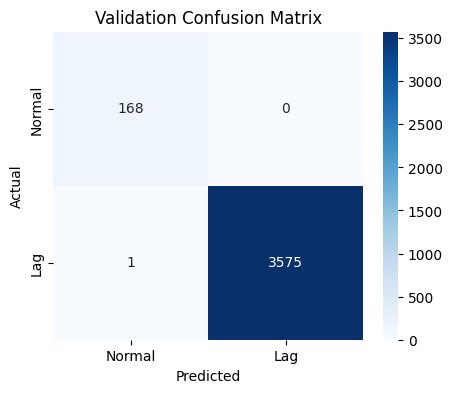

In [ ]:
# Predict
y_val_pred_probs = model.predict(X_val)
y_val_pred = np.argmax(y_val_pred_probs, axis=1)

if len(y_val.shape) > 1:
    y_val_true = np.argmax(y_val, axis=1)
else:
    y_val_true = y_val

print("Validation Accuracy:", accuracy_score(y_val_true, y_val_pred))

print("\nClassification Report (VAL):")
print(classification_report(y_val_true, y_val_pred))

cm_val = confusion_matrix(y_val_true, y_val_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_val, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Lag"],
            yticklabels=["Normal", "Lag"])

plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Test Accuracy: 0.9992156862745099

Classification Report (TEST):
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       144
           1       1.00      1.00      1.00      3681

    accuracy                           1.00      3825
   macro avg       1.00      0.99      0.99      3825
weighted avg       1.00      1.00      1.00      3825



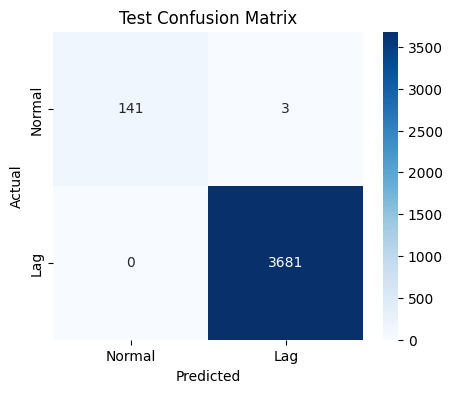

In [ ]:
# Predict
y_test_pred_probs = model.predict(X_test)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)

if len(y_test.shape) > 1:
    y_test_true = np.argmax(y_test, axis=1)
else:
    y_test_true = y_test

print("Test Accuracy:", accuracy_score(y_test_true, y_test_pred))

print("\nClassification Report (TEST):")
print(classification_report(y_test_true, y_test_pred))

cm_test = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Lag"],
            yticklabels=["Normal", "Lag"])

plt.title("Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
model.save("DoorBiLSTM.h5")

In [ ]:
bilstm_model = load_model("DoorBiLSTM.h5")

In [ ]:
def analyze_video(video_path, bilstm_model):
    # Open video file
    cap = cv2.VideoCapture(str(video_path))

    # Get class names from YOLO model
    class_names = model.names

    window_size = 20
    sequence = []
    current_label = "Analyzing..."
    last_valid = None
    while True:
        # Read frame from video
        ret, frame = cap.read()
        if not ret:
            break   # Stop if video ends

        # Run YOLO prediction on frame
        results = model.predict(
            source=frame,
            conf=CONF_THRES,
            verbose=False,
        )

        result = results[0]

        # Get best detection (highest confidence)
        best = get_best_prediction(result)

        # Feature Extraction
        if best:
            feature = list(best["bbox"]) + [best["class"], best["confidence"]]
            last_valid = feature
        else:
            if last_valid is not None:
                feature = last_valid
            else:
                feature = [0,0,0,0,-1,0]

        sequence.append(feature)

        # Window Prediction
        if len(sequence) == window_size:
            import numpy as np

            input_seq = np.array(sequence).reshape(1, window_size, 6)

            pred = bilstm_model.predict(input_seq, verbose=0)
            pred_class = np.argmax(pred)
            conf = np.max(pred)

            current_label = f"{'Lag' if pred_class==1 else 'Normal'} ({conf:.2f})"

            sequence = [sequence[-1]]  # [1–20], [20–40]

        if best:
            # Extract class id
            best_class = best["class"]

            # Extract bounding box coordinates
            x1, y1, x2, y2 = map(int, best["bbox"])
            label = f"{class_names[best_class]} ({best['confidence']:.2f})"     # Create label text (class name + confidence)

            color = CLASS_COLORS.get(best_class, (255, 255, 255))   # Get color for this class

            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)      # Draw bounding box
            cv2.putText(frame, label, (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)                # Draw label text above box

        # LSTM LABEL
        cv2.putText(frame, current_label, (30, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)

        cv2.imshow("Door State Detection", frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

In [ ]:
def process_videos(videos_folder, model):
    videos = [f for f in os.listdir(videos_folder)
              if f.lower().endswith((".mp4"))]
    for file_name in videos:
        video_path = videos_folder / file_name
        analyze_video(video_path, model)

In [ ]:
process_videos(videos_folder, bilstm_model)